First we import the packages

In [3]:
from pygmid import Lookup as look_up
import numpy as np
from prettytable import PrettyTable
import matplotlib.pyplot as plt
from si_prefix import si_format as num2eng
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

Now we import the lookup table

In [4]:
#import the lookup table
nch_path = 'C:/Users/atorralba/My Drive/gmID-Design/PDKs/gf180mcuD/nfet_03v3.mat'
pch_path = 'C:/Users/atorralba/My Drive/gmID-Design/PDKs/gf180mcuD/pfet_03v3.mat'
#nch_path = 'C:/Users/adant/Mi unidad (atorralba@inaoe.mx)/Foss/gmID-Design/PDKs/gf180mcuD/nfet_03v3.mat'
#pch_path = 'C:/Users/adant/Mi unidad (atorralba@inaoe.mx)/Foss/gmID-Design/PDKs/gf180mcuD/pfet_03v3.mat'

nch = look_up(nch_path)
pch = look_up(pch_path)

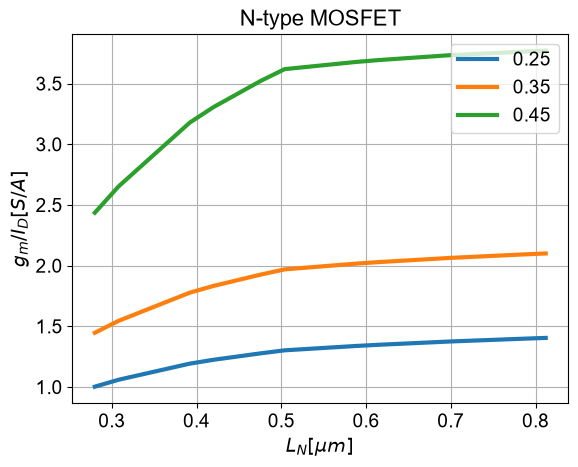

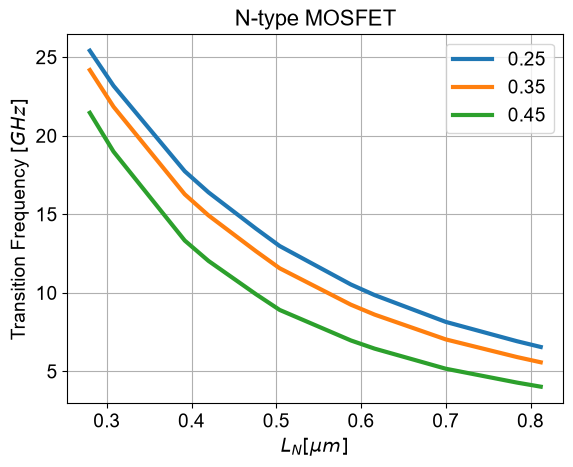

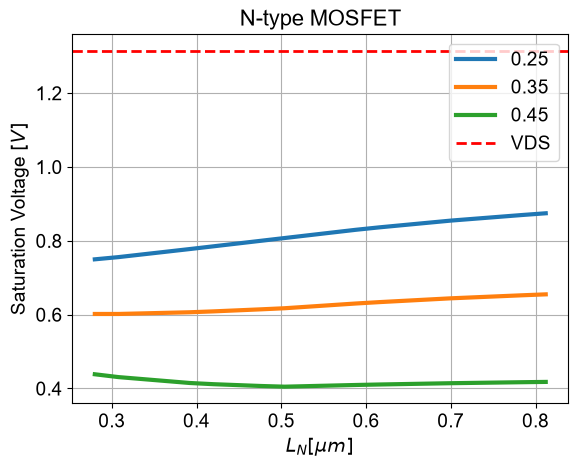

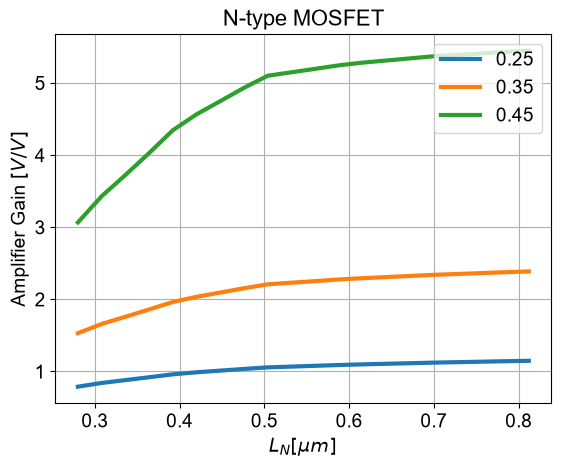

In [5]:
#Specifications
VDD = 3.3
VRatio = np.arange(0.25,0.5,0.1)
VSwing = VDD*VRatio
Vout = VDD-VSwing
Vx = 0.5 #VDS for the tail current mirror
#LN = 0.3
LN = np.arange(min(nch['L']),3*min(nch['L']),0.1*min(nch['L']))


# Amplifier have 2 transistors and a load resistor
VRL = VDD - Vout #Calculate the voltage across the load resistor
# Differential pair transistor

VDSN = Vout - Vx
VGSN = Vout - Vx
VSBN = Vx
VDSB = Vx
VSBB = 0

#print('Operating Points')
#table = PrettyTable()
#table.field_names = ["Parameter", "Value"]
#table.add_row(["VDS", num2eng(float(VDSN)) + " V"])
#table.add_row(["VGS", num2eng(float(VGSN)) + "V"])
#table.add_row(["VRL", num2eng(float(VRL)) + "V"])
#print(table)


VDSatN = np.zeros((len(LN),len(VSwing)))
gmIDN = np.zeros((len(LN),len(VSwing)))
gdsIDN = np.zeros((len(LN),len(VSwing)))
ftN = np.zeros((len(LN),len(VSwing)))
AvoR1 = np.zeros((len(LN),len(VSwing)))


for i, V_Swing in enumerate(VSwing):
    VDSatN[:,i] = nch.look_up('VDSAT', VGS=VGSN[i],VDS = VDSN[i], VSB = VSBN, L=LN)
    gmIDN[:,i] = nch.look_up('GM_ID', VGS=VGSN[i],VDS = VDSN[i], VSB = VSBN, L=LN)
    gdsIDN[:,i] = nch.look_up('GDS_ID', VGS=VGSN[i],VDS = VDSN[i], VSB = VSBN, L=LN)
    ftN[:,i] = nch.look_up('GM_CGG', VGS=VGSN[i],VDS = VDSN[i], VSB = VSBN, L=LN)/(2*np.pi)
    #AvoR1[:,i] = gmIDN[:,i]/(gdsIDN[:,i] + 1./(VRL[i]))


#VDSatN = nch.look_up('VDSAT', VGS=VGSN,VDS = VDSN, VSB = VSBN, L=LN)
#gmIDN = nch.look_up('GM_ID', VGS=VGSN, VDS = VDSN, VSB = VSBN, L=LN)
#gdsIDN = nch.look_up('GDS_ID', VGS=VGSN,VDS = VDSN, VSB = VSBN, L=LN)
#ftN= nch.look_up('GM_CGG', VGS=VGSN,VDS = VDSN, VSB = VSBN, L=LN)/(2*np.pi)
#JDN= nch.look_up('ID_W', VGS=VGSN,VDS = VDSN, VSB = VSBN, L=LN)
#kB = 1.3806488e-23
#Tmp=nch.TEMP
#gammaN=nch.look_up('STH_GM', VGS=VGSN,VDS = VDSN, VSB = VSBN, L=LN)/(4*kB*nch.TEMP)
#cddIDN=nch.look_up('CDD_ID', VGS=VGSN,VDS = VDSN, VSB = VSBN, L=LN)
#cgsIDN=nch.look_up('CGS_ID', VGS=VGSN,VDS = VDSN, VSB = VSBN, L=LN)

AvoR=gmIDN/(gdsIDN + 1./(VRL))

plt.plot(LN, gmIDN, linewidth = 3,label=np.round(VRatio, 2))
plt.title('N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$L_N [\mu m]$',weight='normal',fontsize=14)
plt.ylabel(r'$g_m/I_D [S/A]$', weight='normal',fontsize=14)
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()

plt.plot(LN, ftN*1e-9, linewidth = 3,label=np.round(VRatio, 2))
plt.title('N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$L_N [\mu m]$',weight='normal',fontsize=14)
plt.ylabel(r'Transition Frequency $[GHz]$', weight='normal',fontsize=14)
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()

plt.plot(LN, VDSatN, linewidth = 3,label=np.round(VRatio, 2))
plt.axhline(y=VDSN[-1], color='r', linestyle='--', linewidth=2,label='VDS')
plt.title('N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$L_N [\mu m]$',weight='normal',fontsize=14)
plt.ylabel(r'Saturation Voltage $[V]$', weight='normal',fontsize=14)
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()

plt.plot(LN, AvoR, linewidth = 3,label=np.round(VRatio, 2))
plt.title('N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$L_N [\mu m]$',weight='normal',fontsize=14)
plt.ylabel(r'Amplifier Gain $[V/V]$', weight='normal',fontsize=14)
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()

#print("gmID Driver Parameters")
#print(f"VSwing: {num2eng(VSwing)}V")
#print(f"ftN: {num2eng(ftN)}Hz")

In [82]:
#Specifications
#Specs
CL = 100e-15
fu = 2e9

VDD = 3.3
VRatio = 0.45
VSwing = VDD*VRatio
Vout = VDD-VSwing
LN = 0.4


# Amplifier have 2 transistors and a load resistor
VRL = VDD - Vout #Calculate the voltage across the load resistor
# Differential pair transistor

VDSN = Vout - Vx
VGSN = Vout - Vx
VSBN = Vx
VDSB = Vx
VSBB = 0

print('Operating Points')
table = PrettyTable()
table.field_names = ["Parameter", "Value"]
table.add_row(["VDS", num2eng(float(VDSN)) + " V"])
table.add_row(["VGS", num2eng(float(VGSN)) + "V"])
table.add_row(["VRL", num2eng(float(VRL)) + "V"])
table.add_row(["Vout", num2eng(float(Vout)) + "V"])
print(table)


VDSatN = nch.look_up('VDSAT', VGS=VGSN,VDS = VDSN, VSB = VSBN, L=LN)
gmIDN = nch.look_up('GM_ID', VGS=VGSN, VDS = VDSN, VSB = VSBN, L=LN)
gdsIDN = nch.look_up('GDS_ID', VGS=VGSN,VDS = VDSN, VSB = VSBN, L=LN)
ftN= nch.look_up('GM_CGG', VGS=VGSN,VDS = VDSN, VSB = VSBN, L=LN)/(2*np.pi)
JDN= nch.look_up('ID_W', VGS=VGSN,VDS = VDSN, VSB = VSBN, L=LN)
kB = 1.3806488e-23
temp = 300
gammaN=nch.look_up('STH_GM', VGS=VGSN,VDS = VDSN, VSB = VSBN, L=LN)/(4*kB*temp)
cddIDN=nch.look_up('CDD_ID', VGS=VGSN,VDS = VDSN, VSB = VSBN, L=LN)
cgsIDN=nch.look_up('CGS_ID', VGS=VGSN,VDS = VDSN, VSB = VSBN, L=LN)
AvoR=gmIDN/(gdsIDN + 1./(VRL))


print('gmID Parameters')
table = PrettyTable()
table.field_names = ["Parameter", "Value"]
table.add_row(["VDSatN", num2eng(float(VDSatN)) + " V"])
table.add_row(["gmIDN", num2eng(float(gmIDN)) + "S/A"])
table.add_row(["ftN", num2eng(float(ftN)) + "Hz"])
table.add_row(["AvoR", num2eng(float(AvoR)) + "V/V"])
print(table)



# We perform the iterative procedure to find the required ID for the given CL, fu, and FO.
CddN = 0
niter = 5
CLtot = CL + CddN
for i in range(niter):
    gmN = 2*np.pi*fu*CLtot
    ID = gmN/gmIDN
    WN = ID/JDN
    gdsN = gdsIDN*ID
    CddN = cddIDN*ID
    CgsN = cgsIDN*ID
    CLtot = CL + CddN
    cfu = gmN/( 2*np.pi*CLtot)
    print(f'After {i} iterations, the required ID is {num2eng(float(ID))} A, with WN = {num2eng(float(WN))} m, and total CL = {num2eng(float(CLtot))} F, Current fu = {num2eng(float(cfu))} Hz')

# We calculate VRL from the required ID
# V=RI -> VRL = ID*RL -> RL = VRL/ID
RL = VRL/ID
Av = gmN/(gdsN+(1/RL))
BW = 1/(RL*CLtot*(2*np.pi))

# print the final results in a table including the required ID, WN, WP, CddN, CddP, gm, total CL, and the achieved fu.
final_table = PrettyTable()
final_table.field_names = ["Parameter", "Value", "Unit"]
final_table.add_row(["ID", num2eng(float(ID)), "A"])
final_table.add_row(["WN", num2eng(float(WN)), "um"])
final_table.add_row(["LN", np.round(LN, 2), "um"])
final_table.add_row(["CddN", num2eng(float(CddN)), "F"])
final_table.add_row(["CgsN", num2eng(float(CgsN)), "F"])
final_table.add_row(["gmN", num2eng(float(gmN)), "S"])
final_table.add_row(["Total CL", num2eng(float(CLtot)), "F"])
final_table.add_row(["VRL", num2eng(float(VRL)), "V"])  
final_table.add_row(["RL", num2eng(float(RL)), "Ohm"])
final_table.add_row(["Av", num2eng(float(Av)), "V/V"])
final_table.add_row(["Av", num2eng(float(20*np.log10(Av))), "dB"])
final_table.add_row(["BW", num2eng(float(BW)), "Hz"])
final_table.add_row(["Achieved fu", num2eng(float(cfu)), "Hz"])
print(final_table)


Operating Points
+-----------+--------+
| Parameter | Value  |
+-----------+--------+
|    VDS    | 1.3  V |
|    VGS    | 1.3 V  |
|    VRL    | 1.5 V  |
|    Vout   | 1.8 V  |
+-----------+--------+
gmID Parameters
+-----------+-----------+
| Parameter |   Value   |
+-----------+-----------+
|   VDSatN  | 413.3 m V |
|   gmIDN   |  3.2 S/A  |
|    ftN    |  12.8 GHz |
|    AvoR   |  4.4 V/V  |
+-----------+-----------+
After 0 iterations, the required ID is 389.3 µ A, with WN = 10.0  m, and total CL = 108.5 f F, Current fu = 1.8 G Hz
After 1 iterations, the required ID is 422.2 µ A, with WN = 10.9  m, and total CL = 109.2 f F, Current fu = 2.0 G Hz
After 2 iterations, the required ID is 425.0 µ A, with WN = 11.0  m, and total CL = 109.2 f F, Current fu = 2.0 G Hz
After 3 iterations, the required ID is 425.2 µ A, with WN = 11.0  m, and total CL = 109.2 f F, Current fu = 2.0 G Hz
After 4 iterations, the required ID is 425.2 µ A, with WN = 11.0  m, and total CL = 109.2 f F, Current fu =

In [67]:
#CTLE Calculations
fnyq = 500e6

peaking_db = 6 #dB
peaking_linear = 10**(peaking_db/20)

#Cs = 200e-15
#Rs = 10e3

# 1 = gmN/(gdsN+(1/RL))/(1+gmN*Rs/2)
# 1+gmN*Rs/2 =  gmN/(gdsN+(1/RL))
# gmN*Rs/2 = gmN/(gdsN+(1/RL)) - 1
# Rs = 2*(gmN/(gdsN+(1/RL)) - 1)/gmN

Rs = 2*(gmN/(gdsN+(1/RL)) - 1)/gmN # For a Gain of 0dB at low frequencies
wp = 2*np.pi*fnyq / peaking_linear
# wp = (1+ gmN*Rs/2)/(Rs*Cs)
# wp * Rs * Cs = 1+ gmN*Rs/2
# Cs = (1+ gmN*Rs/2)/(wp*Rs)

Cs = (1+ gmN*Rs/2)/(wp*Rs) # For a Gain of 6dB at fnyq

#wp = (1+ gmN*Rs/2)/(Rs*Cs) #w=2pi*f, f=wp/(2*pi)
wz = 1/(Rs*Cs)
w0 = 1/(RL*CLtot)

wp_hz = wp/(2*np.pi)
wz_hz = wz/(2*np.pi)
w0_hz = w0/(2*np.pi)

DCgain = gmN/(gdsN+(1/RL))/(1+gmN*Rs/2)
ACgain = DCgain*(wp/wz)
Boost = 20*np.log10(wp/wz)

# print the final results in a table
final_table = PrettyTable()
final_table.field_names = ["Parameter", "Value", "Unit"]
final_table.add_row(["Rs", num2eng(float(Rs)), "Ohms"])
final_table.add_row(["Cs", num2eng(float(Cs)), "F"])
final_table.add_row(["DCgain", num2eng(float(20*np.log10(DCgain))), "dB"])
final_table.add_row(["ACgain", num2eng(float(20*np.log10(ACgain))), "dB"])
final_table.add_row(["Boost", num2eng(float(Boost)), "dB"])
final_table.add_row(["wz", num2eng(float(wz_hz)), "Hz"])
final_table.add_row(["w0", num2eng(float(w0_hz)), "Hz"])
final_table.add_row(["wp", num2eng(float(wp_hz)), "Hz"])
final_table.add_row(["fp/fz", num2eng(float(wp_hz/wz_hz)), "Hz"])
final_table.add_row(["fnyq/fp", num2eng(float(fnyq/wp_hz)), "Hz"])
print(final_table)




+-----------+---------+------+
| Parameter |  Value  | Unit |
+-----------+---------+------+
|     Rs    |  5.0 k  | Ohms |
|     Cs    | 562.7 f |  F   |
|   DCgain  |   0.0   |  dB  |
|   ACgain  |  12.9   |  dB  |
|   Boost   |  12.9   |  dB  |
|     wz    |  56.5 M |  Hz  |
|     w0    | 417.2 M |  Hz  |
|     wp    | 250.6 M |  Hz  |
|   fp/fz   |   4.4   |  Hz  |
|  fnyq/fp  |   2.0   |  Hz  |
+-----------+---------+------+


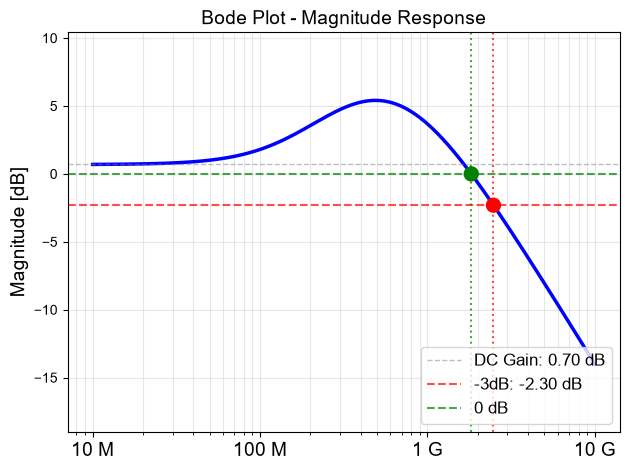


FREQUENCY RESPONSE ANALYSIS
+------------------------+---------+------+
|       Parameter        |  Value  | Unit |
+------------------------+---------+------+
|    DC Gain (Linear)    |  1.0834 | V/V  |
|        DC Gain         |  0.6957 |  dB  |
|        AC Gain         |  5.4102 |  dB  |
|    Bandwidth (-3dB)    |  2.5 G  |  Hz  |
| Unitary Gain Frequency |  1.8 G  |  Hz  |
| Maximum Gain Frequency | 489.5 M |  Hz  |
+------------------------+---------+------+


In [74]:
from scipy import signal
import numpy as np
from matplotlib.ticker import LogLocator, FuncFormatter

Cs = 200e-15
Rs = 5e3

# Transfert function
#               n0 + n1s   
# H(s) = ------------------------
#        d0 + d1s + d2s^2 + d3s^3

#               n1s + n0   
# H(s) = ------------------------
#        d3s^3 + d2s^2 + d1s + d0

#n1 = 2*Cs*gm*Rd*Rs 
#n0 = 2*gm*Rd
#d2 = 2*Cp*Cs*Rd*Rs
#d1 = 2*Cp*Rd + 2*Cs*Rs + Cp*gm*Rd*Rs
#d0 = 2 + gm*Rs

import types

TF = types.SimpleNamespace()

TF.n1 = 2*Cs*gmN*RL*Rs
TF.n0 = 2*gmN*RL
TF.d2 = 2*CLtot*Cs*RL*Rs
TF.d1 = 2*CLtot*RL + 2*Cs*Rs + CLtot*gmN*RL*Rs
TF.d0 = 2 + gmN*Rs

TF.num = [TF.n1, TF.n0]
TF.den = [TF.d2, TF.d1, TF.d0]

# Create transfer function from numerator and denominator
system = signal.TransferFunction(TF.num, TF.den)

# Generate frequency response
# Use logarithmic frequency range from 1 Hz to 10 GHz
w_hz = np.logspace(7, 10, 10000)  # frequencies from 10^7 to 10^10 Hz
w = 2 * np.pi * w_hz  # Convert to rad/s
w, w_mag, w_phase = signal.bode(system, w)

# w_mag is in dB, w_phase is in degrees

# Calculate key metrics
# 1. Low-frequency gain (DC gain)
dc_gain_dB = w_mag[0]
dc_gain_linear = 10**(dc_gain_dB / 20)

# 2. Bandwidth (-3dB point)
# Find the frequency where magnitude drops to -3dB from DC
threshold = dc_gain_dB - 3
idx_3dB = np.argmin(np.abs(w_mag - threshold))
f_3dB_Hz = w_hz[idx_3dB]
f_3dB_rad = w[idx_3dB]

# 3. Unitary gain frequency (0dB crossing)
# Find the frequency where magnitude crosses 0dB
zero_dB_idx = np.argmin(np.abs(w_mag))
f_unity_Hz = w_hz[zero_dB_idx]
f_unity_rad = w[zero_dB_idx]

# 4. AC gain: Maximum gain frequency and value in dB (peak of the magnitude response)
max_gain_idx = np.argmax(w_mag)
f_max_gain_Hz = w_hz[max_gain_idx]
f_max_gain_rad = w[max_gain_idx]
max_gain_value = w_mag[max_gain_idx]

# Create Bode plot
# Magnitude plot
plt.semilogx(w_hz, w_mag, linewidth=2.5, color='blue')
plt.grid(True, which='both', alpha=0.3)
plt.axhline(y=dc_gain_dB, color='gray', linestyle='--', linewidth=1, alpha=0.5, label=f'DC Gain: {dc_gain_dB:.2f} dB')
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'-3dB: {threshold:.2f} dB')
plt.axhline(y=0, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='0 dB')
plt.axvline(x=f_3dB_Hz, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
plt.axvline(x=f_unity_Hz, color='green', linestyle=':', linewidth=1.5, alpha=0.7)
plt.scatter([f_3dB_Hz, f_unity_Hz], [w_mag[idx_3dB], 0], color=['red', 'green'], s=100, zorder=5)
plt.ylabel('Magnitude [dB]', fontsize=14, fontfamily='Arial', weight='normal')
plt.title('Bode Plot - Magnitude Response', fontsize=14, fontfamily='Arial', weight='normal')
plt.legend(prop={'family':'Arial','size':12}, loc='lower right')
plt.ylim([min(w_mag)-5, max(w_mag)+5])
xtickslabel = np.logspace(7, 10, 4)
plt.xticks(xtickslabel,[num2eng(x,0) for x in xtickslabel], weight='normal',fontsize=14);

plt.tight_layout()
plt.show()

# Print summary table
print('\n' + '='*60)
print('FREQUENCY RESPONSE ANALYSIS')
print('='*60)

table = PrettyTable()
table.field_names = ["Parameter", "Value", "Unit"]
table.add_row(["DC Gain (Linear)", f"{dc_gain_linear:.4f}", "V/V"])
table.add_row(["DC Gain", f"{dc_gain_dB:.4f}", "dB"])
table.add_row(["AC Gain", f"{max_gain_value:.4f}", "dB"])
table.add_row(["Bandwidth (-3dB)", f"{num2eng(float(f_3dB_Hz))}", "Hz"])
table.add_row(["Unitary Gain Frequency", f"{num2eng(float(f_unity_Hz))}", "Hz"])
table.add_row(["Maximum Gain Frequency", f"{num2eng(float(f_max_gain_Hz))}", "Hz"])
print(table)

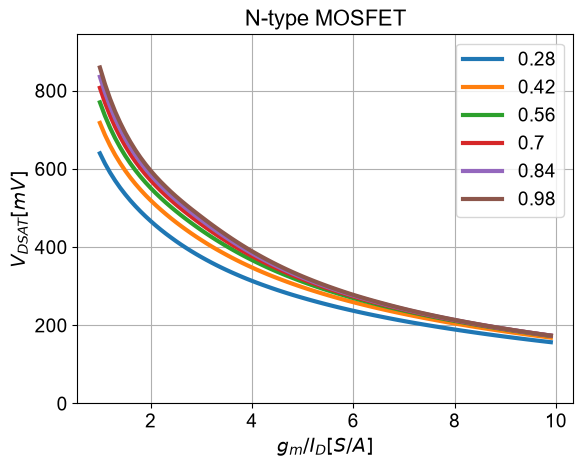

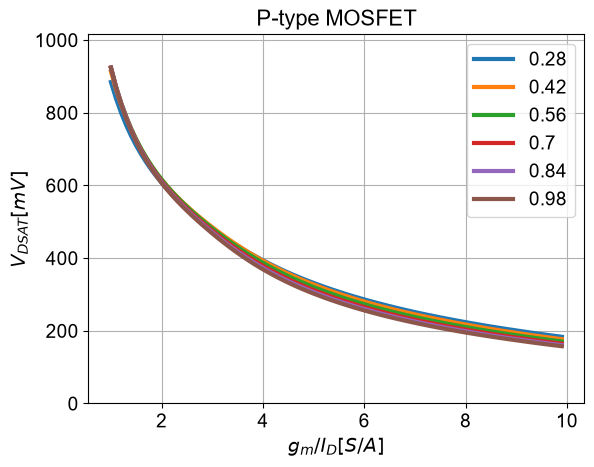

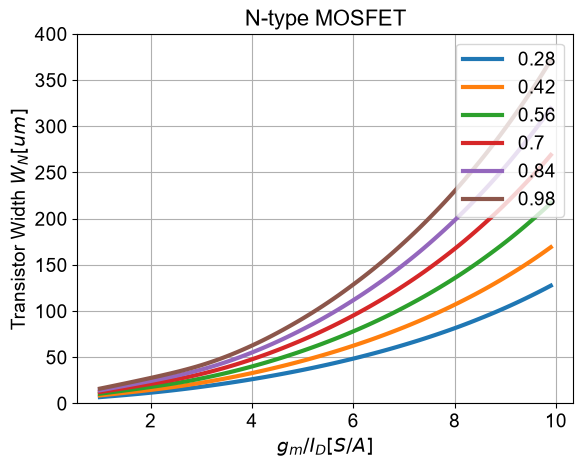

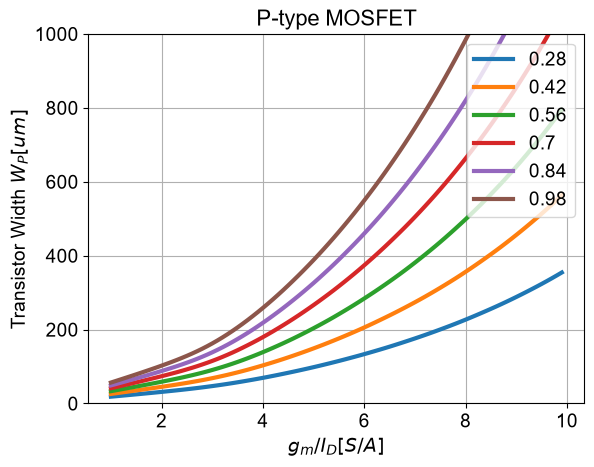

In [75]:
# Plot gmID vs gdsID and VDSat for varying L, at a given VDS and VSB.
IDB = ID*2
VDSB = Vx
VSBB = 0
gmIDNB = np.arange(1, 10, 0.1)
gmIDPB = np.arange(1, 10, 0.1)
LNB = np.arange(min(nch['L']),4*min(nch['L']),0.5*min(nch['L']))
LPB = np.arange(min(pch['L']),4*min(pch['L']),0.5*min(pch['L']))

gdsIDNB = nch.look_up('GDS_ID', GM_ID=gmIDNB, vds=VDSB, vsb=VSBB, L=LNB)
gdsIDPB = pch.look_up('GDS_ID', GM_ID=gmIDPB, vds=VDSB, vsb=VSBB, L=LPB)
JDNB = nch.look_up('ID_W', GM_ID=gmIDNB, vds=VDSB, vsb=VSBB, L=LNB)
JDPB = pch.look_up('ID_W', GM_ID=gmIDPB, vds=VDSB, vsb=VSBB, L=LPB)

#plt.plot(gmIDNB, np.transpose(gdsIDNB), linewidth = 3)
#plt.legend(np.round(LNB, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper left")
#plt.title('N-type MOSFET', weight='normal',fontsize=16)
#plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
#plt.ylabel(r'$g_{ds}/I_D [S/A]$', weight='normal',fontsize=14)
#plt.xticks(weight='normal',fontsize=14)
#plt.yticks(weight='normal',fontsize=14)
#plt.xlim(0, 30)
#plt.grid()
#plt.show()


#plt.plot(gmIDPB, np.transpose(gdsIDPB), linewidth = 3)
#plt.legend(np.round(LNB, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper left")
#plt.title('P-type MOSFET', weight='normal',fontsize=16)
#plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
#plt.ylabel(r'$g_{ds}/I_D [S/A]$', weight='normal',fontsize=14)
#plt.xticks(weight='normal',fontsize=14)
#plt.yticks(weight='normal',fontsize=14)
#plt.xlim(0, 30)
#plt.grid()
#plt.show()


VGSNB = []
VDSatNB = []
VTNB = []
VGSPB = []
VDSatPB = []
VTPB = []

for L in LNB:
    tVGSNB = nch.look_upVGS(GM_ID = gmIDNB, vds = VDSB, vsb = VSBB, L = L)
    VGSNB.append(tVGSNB)
    tVDSATNB = nch.look_up('VDSAT',vgs = tVGSNB, vds=VDSB, vsb=VSBB, L=L)
    VDSatNB.append(tVDSATNB)
    tVTNB = nch.look_up('VT',vgs = tVGSNB, vds=VDSB, vsb=VSBB, L=L)
    VTNB.append(tVTNB)
    tVGSPB = pch.look_upVGS(GM_ID = gmIDPB, vds = VDSB, vsb = VSBB, L = L)
    VGSPB.append(tVGSPB)
    tVDSATPB = pch.look_up('VDSAT',vgs = tVGSPB, vds=VDSB, vsb=VSBB, L=L)
    VDSatPB.append(tVDSATPB)
    tVTPB = pch.look_up('VT',vgs = tVGSPB, vds=VDSB, vsb=VSBB, L=L)
    VTPB.append(tVTPB)

plt.plot(gmIDNB, np.transpose(VDSatNB)*1e3, linewidth = 3, label=LN)
plt.legend(np.round(LNB, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title(r'N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{DSAT} [mV]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.ylim(0, max(np.transpose(VDSatNB).flatten())*1.1*1e3)
#plt.xlim(0, 30)
plt.grid()
plt.show()

plt.plot(gmIDPB, np.transpose(VDSatPB)*1e3, linewidth = 3, label=LPB)
plt.legend(np.round(LPB, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title(r'P-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{DSAT} [mV]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.ylim(0, max(np.transpose(VDSatPB).flatten())*1.1*1e3)
#plt.xlim(0, 30)
plt.grid()
plt.show()


WNB = IDB/JDNB
WPB = IDB/JDPB
gmNB = gmIDNB*IDB
gmPB = gmIDPB*IDB
gdsNB = gdsIDNB*IDB
gdsPB = gdsIDPB*IDB


roN = 1/(gdsNB)
roP = 1/(gdsPB)
roN_casc = (1+gmNB/gdsNB)/gdsNB+(1/gdsNB)
roP_casc = (1+gmPB/gdsPB)/gdsPB+(1/gdsPB)


plt.plot(gmIDNB, np.transpose(WNB), linewidth = 3, label=LPB)
plt.legend(np.round(LPB, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title(r'N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'Transistor Width $ W_N [um]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.ylim(0, 400)
#plt.xlim(0, 30)
plt.grid()
plt.show()

plt.plot(gmIDPB, np.transpose(WPB), linewidth = 3, label=LPB)
plt.legend(np.round(LPB, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title(r'P-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'Transistor Width $ W_P [um]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.ylim(0, 1000)
#plt.xlim(0, 30)
plt.grid()
plt.show()



In [77]:
VDSB = Vx
VSBB = 0
gmIDNB = 5
gmIDPB = 5
LNB = 0.7
LPB = 0.7

gdsIDNB = nch.look_up('GDS_ID', GM_ID=gmIDNB, vds=VDSB, vsb=VSBB, L=LNB)
gdsIDPB = pch.look_up('GDS_ID', GM_ID=gmIDPB, vds=VDSB, vsb=VSBB, L=LPB)
JDNB = nch.look_up('ID_W', GM_ID=gmIDNB, vds=VDSB, vsb=VSBB, L=LNB)
JDPB = pch.look_up('ID_W', GM_ID=gmIDPB, vds=VDSB, vsb=VSBB, L=LPB)

VGSNB = nch.look_upVGS(GM_ID = gmIDNB, vds = VDSB, vsb = VSBB, L =LNB)
VGSPB = pch.look_upVGS(GM_ID = gmIDPB, vds = VDSB, vsb = VSBB, L =LPB)
VDSatNB = nch.look_up('VDSAT',vgs = VGSNB, vds=VDSB, vsb=VSBB, L=LNB)
VDSatPB = pch.look_up('VDSAT',vgs = VGSPB, vds=VDSB, vsb=VSBB, L=LPB)
VTNB = nch.look_up('VT',vgs = VGSNB, vds=VDSB, vsb=VSBB, L=LNB)
VTPB = pch.look_up('VT',vgs = VGSPB, vds=VDSB, vsb=VSBB, L=LPB)

WNB = IDB/JDNB
WPB = IDB/JDPB
gmNB = gmIDNB*IDB
gmPB = gmIDPB*IDB
gdsNB = gdsIDNB*IDB
gdsPB = gdsIDPB*IDB


roN = 1/(gdsNB)
roP = 1/(gdsPB)
roN_casc = (1+gmNB/gdsNB)/gdsNB+(1/gdsNB)
roP_casc = (1+gmPB/gdsPB)/gdsPB+(1/gdsPB)


# For wide swing current mirror
VGSNB2 = 2*VDSatNB + VTNB
VGSPB2 = 2*VDSatPB + VTPB

#Lets find the gmID of a transistor with those values
gmIDNB2 = nch.look_up('GM_ID',vgs = VGSNB2, vds=VDSB, vsb=VSBB, L=LNB)
gmIDPB2 = nch.look_up('GM_ID',vgs = VGSNB2, vds=VDSB, vsb=VSBB, L=LPB)
JDNB2 = nch.look_up('ID_W', GM_ID=gmIDNB2, vds=VDSB, vsb=VSBB, L=LNB)
JDPB2 = pch.look_up('ID_W', GM_ID=gmIDPB2, vds=VDSB, vsb=VSBB, L=LPB)
WNB2 = IDB/JDNB2
WPB2 = IDB/JDPB2


table = PrettyTable()
table.field_names = ["Parameter", "NMOS", "PMOS"]
table.add_row(["gmID", num2eng(float(gmIDNB)) + " S/A", num2eng(float(gmIDPB)) + " S/A"])
table.add_row(["L", str(LNB) + " um", str(LPB) + " um"])
table.add_row(["W", str(round(WNB,1)) + " um", str(round(WPB,1)) + " um"])
table.add_row(["VGS", num2eng(float(VGSNB)) + "V", num2eng(float(VGSPB)) + "V"])
table.add_row(["2*VGS", num2eng(float(2*VGSNB)) + "V", num2eng(float(2*VGSPB)) + "V"])
table.add_row(["VDSat", num2eng(float(VDSatNB)) + "V", num2eng(float(VDSatPB)) + "V"])
table.add_row(["2*VDSat", num2eng(float(2*VDSatNB)) + "V", num2eng(float(2*VDSatPB)) + "V"])
table.add_row(["ro", num2eng(float(roN)) + "Ohms", num2eng(float(roP)) + "Ohms"])
table.add_row(["ro Casc", num2eng(float(roN_casc)) + "Ohms", num2eng(float(roP_casc)) + "Ohms"])
table.add_row(["gm", num2eng(float(gmNB)) + "S", num2eng(float(gmPB)) + "S"])
table.add_row(["ID", num2eng(float(IDB)) + "A", num2eng(float(IDB)) + "A"])
print(table)

print('Cascode Bias Generator')
table = PrettyTable()
table.field_names = ["Parameter", "NMOS", "PMOS"]
table.add_row(["gmID", num2eng(float(gmIDNB2)) + " S/A", num2eng(float(gmIDPB2)) + " S/A"])
table.add_row(["L", str(LNB) + " um", str(LPB) + " um"])
table.add_row(["W", str(round(WNB2,1)) + " um", str(round(WPB2,1)) + " um"])
table.add_row(["VGS", num2eng(float(VGSNB2)) + "V", num2eng(float(VGSPB2)) + "V"])
table.add_row(["ID", num2eng(float(IDB)) + "A", num2eng(float(IDB)) + "A"])
print(table)


+-----------+-------------+-------------+
| Parameter |     NMOS    |     PMOS    |
+-----------+-------------+-------------+
|    gmID   |   5.0  S/A  |   5.0  S/A  |
|     L     |    0.7 um   |    0.7 um   |
|     W     |   68.8 um   |   266.3 um  |
|    VGS    |    1.0 V    |    1.1 V    |
|   2*VGS   |    2.1 V    |    2.3 V    |
|   VDSat   |   317.6 mV  |   312.1 mV  |
|  2*VDSat  |   635.3 mV  |   624.3 mV  |
|     ro    |  13.2 kOhms |  14.9 kOhms |
|  ro Casc  | 765.0 kOhms | 972.5 kOhms |
|     gm    |    4.3 mS   |    4.3 mS   |
|     ID    |   850.5 µA  |   850.5 µA  |
+-----------+-------------+-------------+
Cascode Bias Generator
+-----------+----------+----------+
| Parameter |   NMOS   |   PMOS   |
+-----------+----------+----------+
|    gmID   | 2.4  S/A | 2.4  S/A |
|     L     |  0.7 um  |  0.7 um  |
|     W     | 24.5 um  | 86.4 um  |
|    VGS    |  1.3 V   |  1.4 V   |
|     ID    | 850.5 µA | 850.5 µA |
+-----------+----------+----------+


Now we will learn to design current mirrors

For this, we will see 3 commonly used current mirror topologies.
Simple
Cascode
Low-Voltage or High-Swing Cascode

First we will start with the Simple current mirror

This is a transistor that operates as a current source.
We need to consider what is important in a current mirror, fortunately the current mirror does not carry any signal so the important parameters are:

- Output Impedance
- Transistor Size
- VDSat 
- Flicker and Thermal noise*

The output impedance of a simple current mirror is:

ro = 1/gds

ro = 1/ID/gds/ID = 1/ID/gdsID = 1/(gdsID*ID)

We can sweep gmID and L to define VDSat
Once VDSat is set, we can Sweep L and ID to see how ro varies



In [ ]:
# Plot gmID vs gdsID and VDSat for varying L, at a given VDS and VSB.
VDS = max(nch['VDS'])/2
VSB = 0
gmIDN = np.arange(2, 28, 0.1)
gmIDP = np.arange(2, 20, 0.1)
LN = np.arange(min(nch['L']),4*min(nch['L']),0.5*min(nch['L']))
LP = np.arange(min(pch['L']),4*min(pch['L']),0.5*min(pch['L']))

gdsIDN = nch.look_up('GDS_ID', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
gdsIDP = pch.look_up('GDS_ID', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)

plt.plot(gmIDN, np.transpose(gdsIDN), linewidth = 3)
plt.legend(np.round(LN, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper left")
plt.title('N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$g_{ds}/I_D [S/A]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.xlim(0, 30)
plt.grid()
plt.show()


plt.plot(gmIDP, np.transpose(gdsIDP), linewidth = 3)
plt.legend(np.round(LN, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper left")
plt.title('P-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$g_{ds}/I_D [S/A]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.xlim(0, 30)
plt.grid()
plt.show()


VGSN = []
VDSatN = []
VGSP = []
VDSatP = []
for L in LN:
    tVGSN = nch.look_upVGS(GM_ID = gmIDN, vds = VDS, vsb = VSB, L = L)
    VGSN.append(tVGSN)
    tVDSATN = nch.look_up('VDSAT',vgs = tVGSN, vds=VDS, vsb=VSB, L=L)
    VDSatN.append(tVDSATN)
    tVGSP = pch.look_upVGS(GM_ID = gmIDP, vds = VDS, vsb = VSB, L = L)
    VGSP.append(tVGSP)
    tVDSATP = pch.look_up('VDSAT',vgs = tVGSP, vds=VDS, vsb=VSB, L=L)
    VDSatP.append(tVDSATP)

plt.plot(gmIDN, np.transpose(VDSatN)*1e3, linewidth = 3, label=LN)
plt.legend(np.round(LN, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title(r'N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{DSAT} [mV]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.ylim(0, max(np.transpose(VDSatN).flatten())*1.1*1e3)
plt.xlim(0, 30)
plt.grid()
plt.show()

plt.plot(gmIDP, np.transpose(VDSatP)*1e3, linewidth = 3, label=LP)
plt.legend(np.round(LN, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title(r'P-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{DSAT} [mV]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.ylim(0, max(np.transpose(VDSatP).flatten())*1.1*1e3)
plt.xlim(0, 30)
plt.grid()
plt.show()





In [ ]:
VDS = max(nch['VDS'])/2
VSB = 0
gmIDN = 10
gmIDP = 10
LN = 0.8
LP = 0.6
ID = 100e-6

gdsIDN = nch.look_up('GDS_ID', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
gdsIDP = pch.look_up('GDS_ID', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)
JDN = nch.look_up('ID_W', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
JDP = pch.look_up('ID_W', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)

VGSN = nch.look_upVGS(GM_ID = gmIDN, vds = VDS, vsb = VSB, L =LN)
VGSP = pch.look_upVGS(GM_ID = gmIDP, vds = VDS, vsb = VSB, L =LP)
VDSatN = nch.look_up('VDSAT',vgs = VGSN, vds=VDS, vsb=VSB, L=LN)
VDSatP = pch.look_up('VDSAT',vgs = VGSP, vds=VDS, vsb=VSB, L=LP)
VTN = nch.look_up('VT',vgs = VGSN, vds=VDS, vsb=VSB, L=LN)
VTP = pch.look_up('VT',vgs = VGSP, vds=VDS, vsb=VSB, L=LP)

WN = ID/JDN
WP = ID/JDP
gmN = gmIDN*ID
gmP = gmIDP*ID
gdsN = gdsIDN*ID
gdsP = gdsIDP*ID


roN = 1/(gdsN)
roP = 1/(gdsP)
roN_casc = (1+gmN/gdsN)/gdsN+(1/gdsN)
roP_casc = (1+gmP/gdsP)/gdsP+(1/gdsP)


# For wide swing current mirror
VGSN2 = 2*VDSatN + VTN
VGSP2 = 2*VDSatP + VTP

#Lets find the gmID of a transistor with those values
gmIDN2 = nch.look_up('GM_ID',vgs = VGSN2, vds=VDS, vsb=VSB, L=LN)
gmIDP2 = nch.look_up('GM_ID',vgs = VGSN2, vds=VDS, vsb=VSB, L=LP)
JDN2 = nch.look_up('ID_W', GM_ID=gmIDN2, vds=VDS, vsb=VSB, L=LN)
JDP2 = pch.look_up('ID_W', GM_ID=gmIDP2, vds=VDS, vsb=VSB, L=LP)
WN2 = ID/JDN2
WP2 = ID/JDP2


table = PrettyTable()
table.field_names = ["Parameter", "NMOS", "PMOS"]
table.add_row(["gmID", num2eng(float(gmIDN)) + " S/A", num2eng(float(gmIDP)) + " S/A"])
table.add_row(["L", str(LN) + " um", str(LP) + " um"])
table.add_row(["W", str(round(WN,1)) + " um", str(round(WP,1)) + " um"])
table.add_row(["VGS", num2eng(float(VGSN)) + "V", num2eng(float(VGSP)) + "V"])
table.add_row(["2*VGS", num2eng(float(2*VGSN)) + "V", num2eng(float(2*VGSP)) + "V"])
table.add_row(["VDSat", num2eng(float(VDSatN)) + "V", num2eng(float(VDSatP)) + "V"])
table.add_row(["2*VDSat", num2eng(float(2*VDSatN)) + "V", num2eng(float(2*VDSatP)) + "V"])
table.add_row(["ro", num2eng(float(roN)) + "Ohms", num2eng(float(roP)) + "Ohms"])
table.add_row(["ro Casc", num2eng(float(roN_casc)) + "Ohms", num2eng(float(roP_casc)) + "Ohms"])
table.add_row(["gm", num2eng(float(gmN)) + "S", num2eng(float(gmP)) + "S"])
table.add_row(["ID", num2eng(float(ID)) + "A", num2eng(float(ID)) + "A"])
print(table)

print('Cascode Bias Generator')
table = PrettyTable()
table.field_names = ["Parameter", "NMOS", "PMOS"]
table.add_row(["gmID", num2eng(float(gmIDN2)) + " S/A", num2eng(float(gmIDP2)) + " S/A"])
table.add_row(["L", str(LN) + " um", str(LP) + " um"])
table.add_row(["W", str(round(WN2,1)) + " um", str(round(WP2,1)) + " um"])
table.add_row(["VGS", num2eng(float(VGSN2)) + "V", num2eng(float(VGSP2)) + "V"])
table.add_row(["ID", num2eng(float(ID)) + "A", num2eng(float(ID)) + "A"])
print(table)
